# Titanic Survival Analysis
**Prompt:** *Who survived the Titanic, and what made the difference?*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.precision = 2

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


### Clean the data

In [3]:
# remove duplicate rows
df = df.drop_duplicates()

# remove rows with missing values
df = df.dropna()

print('Clean passenger records:', len(df))

Clean passenger records: 181


### Overall survival

In [4]:
# survived is 1 or 0, so the average is the survival rate
print(round(df['survived'].mean(), 2))

0.67


### Survival by class

In [5]:
rate = df.groupby('class')['survived'].mean()
rate

class
First     0.67
Second    0.80
Third     0.50
Name: survived, dtype: float64

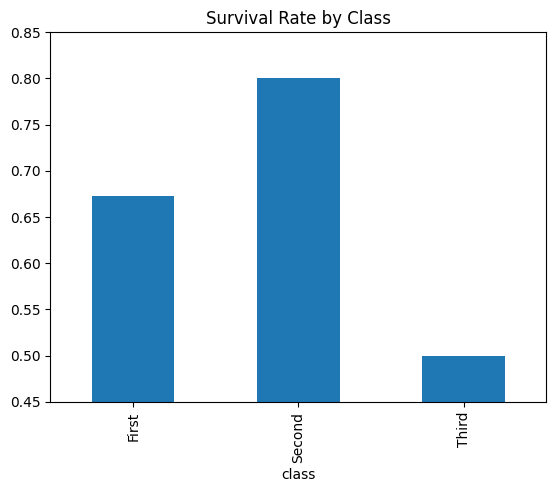

In [6]:
rate.plot(kind='bar')
plt.ylim(0.45, 0.85)
plt.title('Survival Rate by Class')
plt.show()

### Other factors

In [7]:
df.groupby('sex')['survived'].mean()

sex
female    0.93
male      0.44
Name: survived, dtype: float64

In [8]:
# correlation between ticket price and survival
print(round(df['fare'].corr(df['survived']), 2))

0.13


In [9]:
df.groupby('embark_town')['survived'].mean()

embark_town
Cherbourg      0.73
Queenstown     0.50
Southampton    0.64
Name: survived, dtype: float64

## Findings
1. **About two thirds of passengers (67%) survived.**
2. **Second class had the best survival rate (80%)**, ahead of first class (67%). Ticket class was not the deciding factor.
3. **Women survived at more than twice the rate of men** (93% vs 44%).
4. **Fare had almost no relationship with survival** (r = 0.13). Paying more did not buy safety.
5. **Boarding at Cherbourg improved survival odds** (73% vs 64% for Southampton).